# 01 Data Preparation

This notebook loads PulseDB subsets, removes implausible records, creates a subject-level train/validation split, computes normalization statistics, and saves processed artifacts for downstream notebooks.

In [ ]:
!pip install -q mat73

In [ ]:
import gc
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/cuffless-bp-pulsedb")
DATA_DIR = Path("/content/drive/MyDrive/pulsedb")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.data import (
    load_mat_file,
    valid_range_mask,
    apply_mask,
    summarize_split,
    summarize_indices,
    make_group_split,
    compute_signal_stats,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FILE_PATHS = {
    "train": DATA_DIR / "VitalDB_Train_Subset.mat",
    "calbased": DATA_DIR / "VitalDB_CalBased_Test_Subset.mat",
    "calfree": DATA_DIR / "VitalDB_CalFree_Test_Subset.mat",
}

summary_rows = []

In [ ]:
import os
import kagglehub
from google.colab import drive

path = kagglehub.dataset_download(
    "weinanwangrutgers/pulsedb-balanced-training-and-testing"
)

TRAIN_PATH = os.path.join(path, "VitalDB_Train_Subset.mat")

100%|██████████| 17.3G/17.3G [02:46<00:00, 111MB/s]

Extracting files...


In [ ]:
df_train, ECG_train, PPG_train, ABP_train = load_mat_file(TRAIN_PATH)
# df_train, ECG_train, PPG_train, ABP_train = load_mat_file(FILE_PATHS["train"])

summary_rows.append(summarize_split(df_train, "train", "raw"))

mask_train = valid_range_mask(df_train)
removed_train = int((~mask_train).sum())
removed_pct_train = removed_train / len(df_train)

df_train, ECG_train, PPG_train, ABP_train = apply_mask(
    df_train, ECG_train, PPG_train, ABP_train, mask_train
)

train_clean_summary = summarize_split(df_train, "train", "clean")
train_clean_summary["removed_segments"] = removed_train
train_clean_summary["removed_pct"] = removed_pct_train
summary_rows.append(train_clean_summary)

train_idx, val_idx = make_group_split(
    df_train,
    group_col="Subject",
    test_size=0.1,
    random_state=42,
)

summary_rows.append(summarize_indices(df_train, train_idx, "train_fit"))
summary_rows.append(summarize_indices(df_train, val_idx, "val"))

signal_stats = compute_signal_stats(ECG_train, PPG_train, train_idx)

df_train.to_csv(PROCESSED_DIR / "train_meta.csv", index=False)
np.save(PROCESSED_DIR / "train_ecg.npy", ECG_train)
np.save(PROCESSED_DIR / "train_ppg.npy", PPG_train)
np.save(PROCESSED_DIR / "train_idx.npy", train_idx)
np.save(PROCESSED_DIR / "val_idx.npy", val_idx)
pd.DataFrame([signal_stats]).to_csv(PROCESSED_DIR / "signal_stats.csv", index=False)

rng = np.random.default_rng(42)
abp_sample_size = min(50000, len(ABP_train))
abp_sample_idx = np.sort(rng.choice(len(ABP_train), size=abp_sample_size, replace=False))
np.save(PROCESSED_DIR / "abp_train_sample_idx.npy", abp_sample_idx)
np.save(PROCESSED_DIR / "abp_train_sample.npy", ABP_train[abp_sample_idx])

print(pd.DataFrame(summary_rows).tail(4))
print(signal_stats)

       split  stage  n_segments  n_subjects  male_share   mean_age  \
0      train    raw      465480        1293    0.576953  58.980983   
1      train  clean      461429        1285    0.577688  59.290316   
2  train_fit  ready      415062        1156    0.566853  59.101785   
3        val  ready       46367         129    0.674682  60.977980   

     mean_sbp   mean_dbp  removed_segments  removed_pct  
0  115.476681  62.915730               NaN          NaN  
1  115.756535  63.082062            4051.0     0.008703  
2  115.718447  63.057071               NaN          NaN  
3  116.097483  63.305775               NaN          NaN  
{'ecg_mean': 0.2419050393170642, 'ecg_std': 0.1940083027847364, 'ppg_mean': 0.3427026404699259, 'ppg_std': 0.2924610338197528}


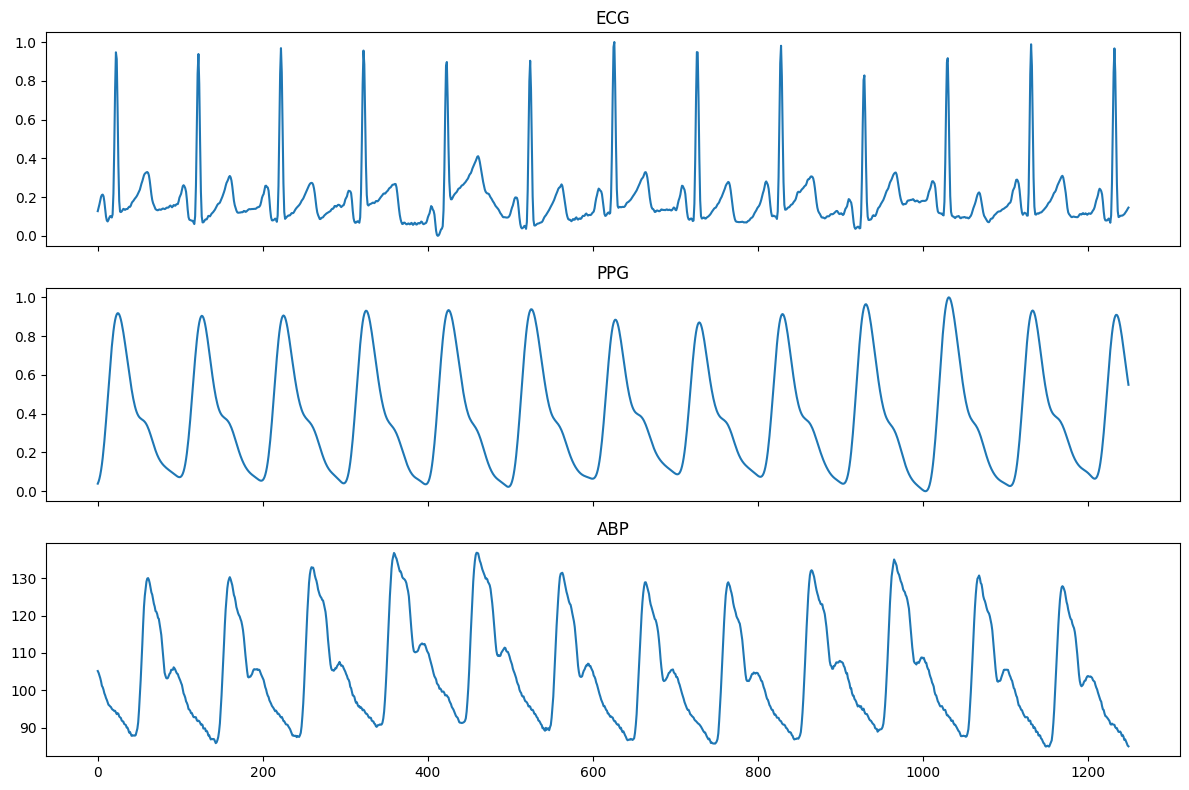

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ECG_train[0])
axes[0].set_title("ECG")

axes[1].plot(PPG_train[0])
axes[1].set_title("PPG")

axes[2].plot(ABP_train[0])
axes[2].set_title("ABP")

fig.tight_layout()
fig.savefig(FIG_DIR / "signal_samples.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
del df_train, ECG_train, PPG_train, ABP_train
gc.collect()

9500

In [ ]:
def process_eval_split(split_name, file_path, summary_rows):
    df, ECG, PPG, ABP = load_mat_file(file_path)

    summary_rows.append(summarize_split(df, split_name, "raw"))

    mask = valid_range_mask(df)
    removed_segments = int((~mask).sum())
    removed_pct = removed_segments / len(df)

    df, ECG, PPG, ABP = apply_mask(df, ECG, PPG, ABP, mask)

    clean_summary = summarize_split(df, split_name, "clean")
    clean_summary["removed_segments"] = removed_segments
    clean_summary["removed_pct"] = removed_pct
    summary_rows.append(clean_summary)

    df.to_csv(PROCESSED_DIR / f"{split_name}_meta.csv", index=False)
    np.save(PROCESSED_DIR / f"{split_name}_ecg.npy", ECG)
    np.save(PROCESSED_DIR / f"{split_name}_ppg.npy", PPG)

    del df, ECG, PPG, ABP
    gc.collect()

In [ ]:
process_eval_split("calbased", FILE_PATHS["calbased"], summary_rows)

In [ ]:
process_eval_split("calfree", FILE_PATHS["calfree"], summary_rows)

In [ ]:
dataset_summary = pd.DataFrame(summary_rows)
dataset_summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)
dataset_summary

,split,stage,n_segments,n_subjects,male_share,mean_age,mean_sbp,mean_dbp,removed_segments,removed_pct
0,train,raw,465480,1293,0.576953,58.980983,115.476681,62.915730,NaN,NaN
1,train,clean,461429,1285,0.577688,59.290316,115.756535,63.082062,4051.0,0.008703
2,train_fit,ready,415062,1156,0.566853,59.101785,115.718447,63.057071,NaN,NaN
3,val,ready,46367,129,0.674682,60.977980,116.097483,63.305775,NaN,NaN
4,calbased,raw,51720,1293,0.576953,58.980684,115.499449,62.936572,NaN,NaN
5,calbased,clean,51288,1285,0.577757,59.300402,115.759158,63.091819,432.0,0.008353
6,calfree,raw,57600,144,0.597222,58.166667,115.429877,63.024345,NaN,NaN
7,calfree,clean,57521,144,0.596826,58.159211,115.492612,63.053298,79.0,0.001372


In [ ]:
# check
print("train_ecg:", np.load(PROCESSED_DIR / "train_ecg.npy", mmap_mode="r").shape)
print("train_ppg:", np.load(PROCESSED_DIR / "train_ppg.npy", mmap_mode="r").shape)
print("train_idx:", np.load(PROCESSED_DIR / "train_idx.npy").shape)
print("val_idx:", np.load(PROCESSED_DIR / "val_idx.npy").shape)
print("calbased_ecg:", np.load(PROCESSED_DIR / "calbased_ecg.npy", mmap_mode="r").shape)
print("calfree_ecg:", np.load(PROCESSED_DIR / "calfree_ecg.npy", mmap_mode="r").shape)
print("abp_train_sample:", np.load(PROCESSED_DIR / "abp_train_sample.npy", mmap_mode="r").shape)

train_ecg: (461429, 1250)
train_ppg: (461429, 1250)
train_idx: (415062,)
val_idx: (46367,)
calbased_ecg: (51288, 1250)
calfree_ecg: (57521, 1250)
abp_train_sample: (50000, 1250)
